# Conversion Rate Challenge — EDA

L'objectif est de prédire si un visiteur va convertir (s'inscrire) sur un site e-commerce à partir de ses caractéristiques.

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

df = pd.read_csv('../data/raw/conversion_data_train.csv')
print(f"{df.shape[0]} lignes, {df.shape[1]} colonnes")
df.head()

284580 lignes, 6 colonnes


,country,age,new_user,source,total_pages_visited,converted
0,China,22,1,Direct,2,0
1,UK,21,1,Ads,3,0
2,Germany,20,0,Seo,14,1
3,US,23,1,Seo,3,0
4,US,28,1,Direct,3,0


## 1. Aperçu du dataset

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284580 entries, 0 to 284579
Data columns (total 6 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   country              284580 non-null  object
 1   age                  284580 non-null  int64 
 2   new_user             284580 non-null  int64 
 3   source               284580 non-null  object
 4   total_pages_visited  284580 non-null  int64 
 5   converted            284580 non-null  int64 
dtypes: int64(4), object(2)
memory usage: 13.0+ MB


In [9]:
df.describe()

,age,new_user,total_pages_visited,converted
count,284580.000000,284580.000000,284580.000000,284580.000000
mean,30.564203,0.685452,4.873252,0.032258
std,8.266789,0.464336,3.341995,0.176685
min,17.000000,0.000000,1.000000,0.000000
25%,24.000000,0.000000,2.000000,0.000000
50%,30.000000,1.000000,4.000000,0.000000
75%,36.000000,1.000000,7.000000,0.000000
max,123.000000,1.000000,29.000000,1.000000


## 2. Valeurs manquantes et doublons

In [10]:
print("Valeurs manquantes :")
print(df.isnull().sum())

n_dupes = df.drop('converted', axis=1).duplicated().sum()
print(f"\nDoublons (hors cible) : {n_dupes}")

Valeurs manquantes :
country                0
age                    0
new_user               0
source                 0
total_pages_visited    0
converted              0
dtype: int64

Doublons (hors cible) : 270638


Pas de valeurs manquantes. Les doublons correspondent à des visiteurs avec les mêmes caractéristiques — on les garde car des profils similaires peuvent avoir des comportements différents (l'un convertit, l'autre non).

## 3. Variable cible — taux de conversion

Taux de conversion : 3.2%
Non-convertis      : 96.8%


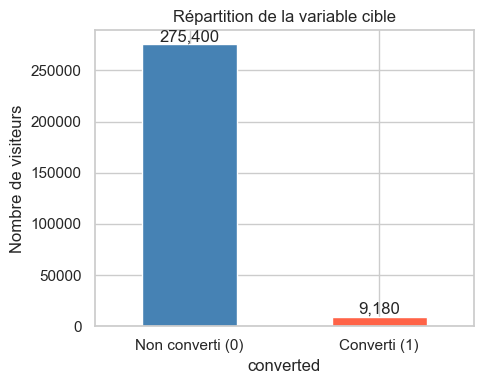

In [11]:
taux = df['converted'].value_counts(normalize=True) * 100
print(f"Taux de conversion : {taux[1]:.1f}%")
print(f"Non-convertis      : {taux[0]:.1f}%")

fig, ax = plt.subplots(figsize=(5, 4))
df['converted'].value_counts().plot(kind='bar', ax=ax,
    color=['steelblue', 'tomato'], rot=0)
ax.set_xticklabels(['Non converti (0)', 'Converti (1)'])
ax.set_title('Répartition de la variable cible')
ax.set_ylabel('Nombre de visiteurs')
for p in ax.patches:
    ax.annotate(f'{p.get_height():,}', (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom')
plt.tight_layout()
plt.show()

**Observation :** Le dataset est fortement déséquilibré — seulement ~3% de conversions. Il faudra en tenir compte dans la modélisation (class_weight, F1-score).

## 4. Variables numériques

### 4.1 Distribution de l'âge

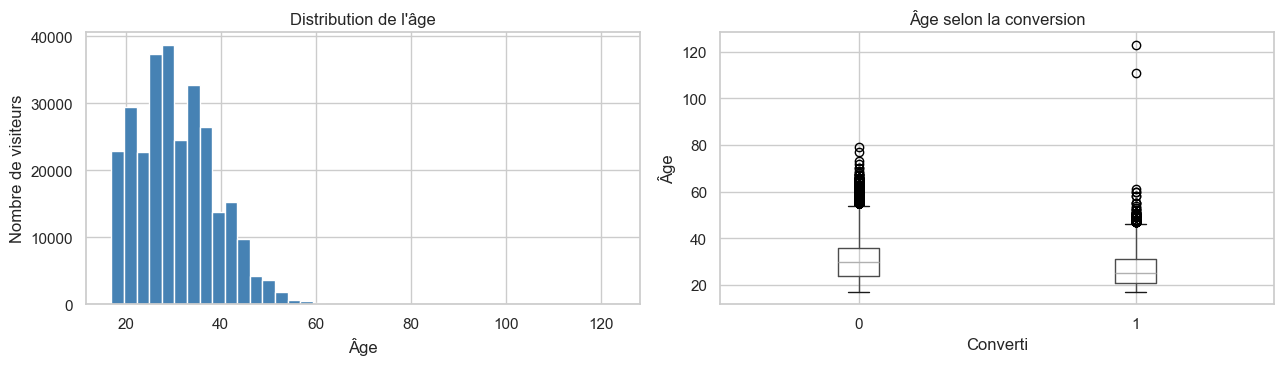

Âge min : 17  |  max : 123  |  médiane : 30.0
Valeurs aberrantes (age > 80) : 2


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

df['age'].hist(bins=40, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Distribution de l\'âge')
axes[0].set_xlabel('Âge')
axes[0].set_ylabel('Nombre de visiteurs')

df.boxplot(column='age', by='converted', ax=axes[1])
axes[1].set_title('Âge selon la conversion')
axes[1].set_xlabel('Converti')
axes[1].set_ylabel('Âge')
plt.suptitle('')
plt.tight_layout()
plt.show()

print(f"Âge min : {df['age'].min()}  |  max : {df['age'].max()}  |  médiane : {df['age'].median()}")
print(f"Valeurs aberrantes (age > 80) : {(df['age'] > 80).sum()}")

**Observation :** La distribution est étalée avec quelques valeurs très élevées (> 80 ans) qui semblent aberrantes. Les convertis et non-convertis ont des distributions d'âge proches — l'âge seul n'est pas très discriminant.

### 4.2 Distribution des pages visitées

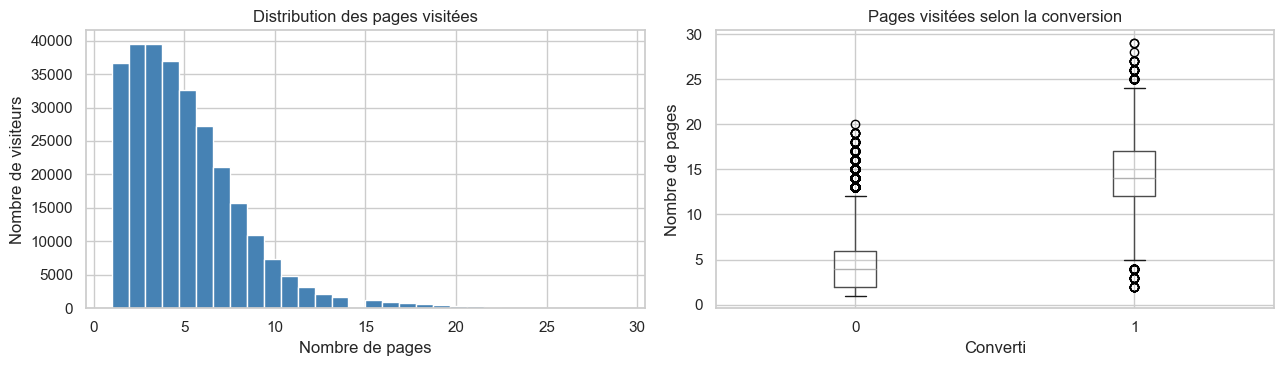

              count  mean  std  min   25%   50%   75%   max
converted                                                  
0          275400.0   4.6  2.8  1.0   2.0   4.0   6.0  20.0
1            9180.0  14.6  4.0  2.0  12.0  14.0  17.0  29.0


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

df['total_pages_visited'].hist(bins=30, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Distribution des pages visitées')
axes[0].set_xlabel('Nombre de pages')
axes[0].set_ylabel('Nombre de visiteurs')

df.boxplot(column='total_pages_visited', by='converted', ax=axes[1])
axes[1].set_title('Pages visitées selon la conversion')
axes[1].set_xlabel('Converti')
axes[1].set_ylabel('Nombre de pages')
plt.suptitle('')
plt.tight_layout()
plt.show()

print(df.groupby('converted')['total_pages_visited'].describe().round(1))

**Observation :** Les visiteurs qui convertissent ont visité beaucoup plus de pages (médiane ~15) que ceux qui ne convertissent pas (médiane ~3). C'est probablement la variable la plus prédictive du dataset.

## 5. Variables catégorielles

### 5.1 Pays

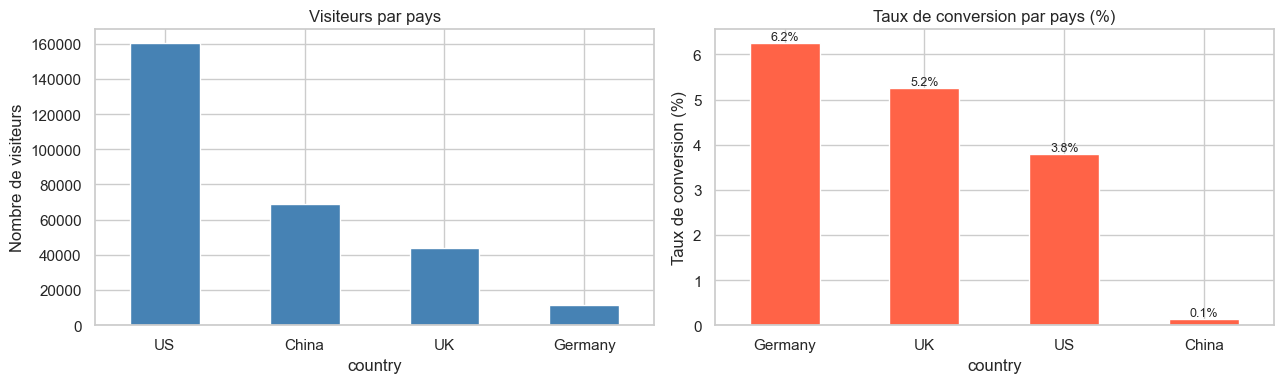

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

country_counts = df['country'].value_counts()
country_counts.plot(kind='bar', ax=axes[0], color='steelblue', rot=0)
axes[0].set_title('Visiteurs par pays')
axes[0].set_ylabel('Nombre de visiteurs')

taux_country = df.groupby('country')['converted'].mean().sort_values(ascending=False) * 100
taux_country.plot(kind='bar', ax=axes[1], color='tomato', rot=0)
axes[1].set_title('Taux de conversion par pays (%)')
axes[1].set_ylabel('Taux de conversion (%)')
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.1f}%',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

**Observation :** Le trafic est dominé par les US et la Chine. Malgré le volume, la Chine a le taux de conversion le plus bas (~1%). L'Allemagne a le meilleur taux (~6%).

### 5.2 Source de trafic

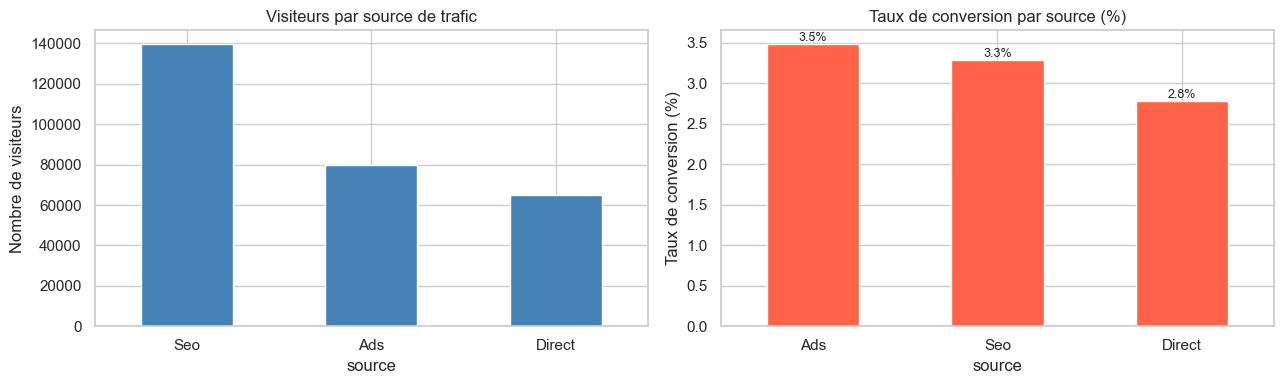

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

df['source'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue', rot=0)
axes[0].set_title('Visiteurs par source de trafic')
axes[0].set_ylabel('Nombre de visiteurs')

taux_source = df.groupby('source')['converted'].mean().sort_values(ascending=False) * 100
taux_source.plot(kind='bar', ax=axes[1], color='tomato', rot=0)
axes[1].set_title('Taux de conversion par source (%)')
axes[1].set_ylabel('Taux de conversion (%)')
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.1f}%',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

**Observation :** Les trois sources ont des taux de conversion proches (~3%). Le SEO amène le plus de trafic mais ne convertit pas mieux que les Ads.

### 5.3 Nouveau vs ancien utilisateur

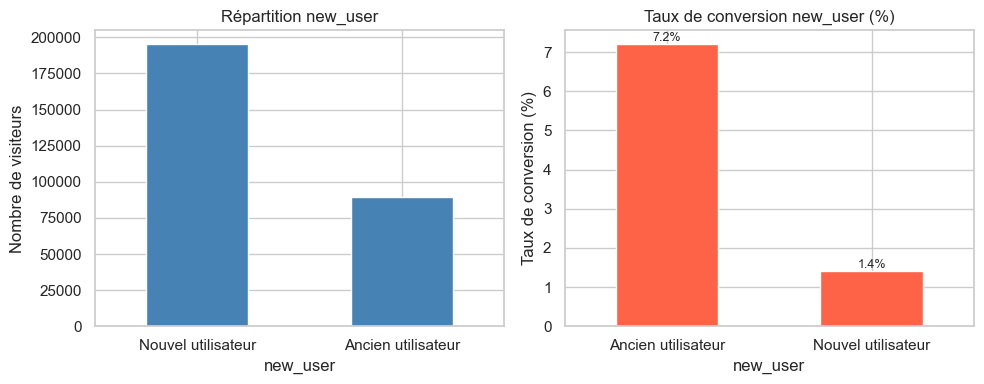

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

labels = {0: 'Ancien utilisateur', 1: 'Nouvel utilisateur'}
df['new_user'].map(labels).value_counts().plot(kind='bar', ax=axes[0], color='steelblue', rot=0)
axes[0].set_title('Répartition new_user')
axes[0].set_ylabel('Nombre de visiteurs')

taux_user = df.groupby('new_user')['converted'].mean() * 100
taux_user.index = taux_user.index.map(labels)
taux_user.plot(kind='bar', ax=axes[1], color='tomato', rot=0)
axes[1].set_title('Taux de conversion new_user (%)')
axes[1].set_ylabel('Taux de conversion (%)')
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.1f}%',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

**Observation :** Les anciens utilisateurs convertissent bien plus (~9%) que les nouveaux (~2%). C'est cohérent : quelqu'un qui revient sur le site est déjà intéressé.

## 6. Corrélation avec la cible

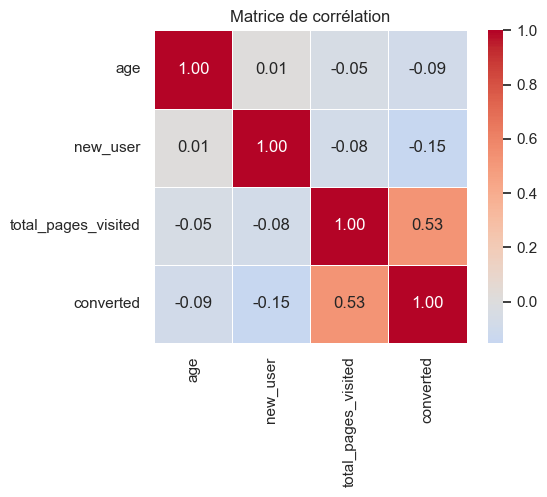

In [17]:
corr = df[['age', 'new_user', 'total_pages_visited', 'converted']].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5)
plt.title('Matrice de corrélation')
plt.tight_layout()
plt.show()

**Observation :** `total_pages_visited` est la variable la plus corrélée avec `converted` (0.39). `new_user` est négativement corrélée (-0.15) : les nouveaux utilisateurs convertissent moins.

## 7. Pages visitées selon la conversion et la source

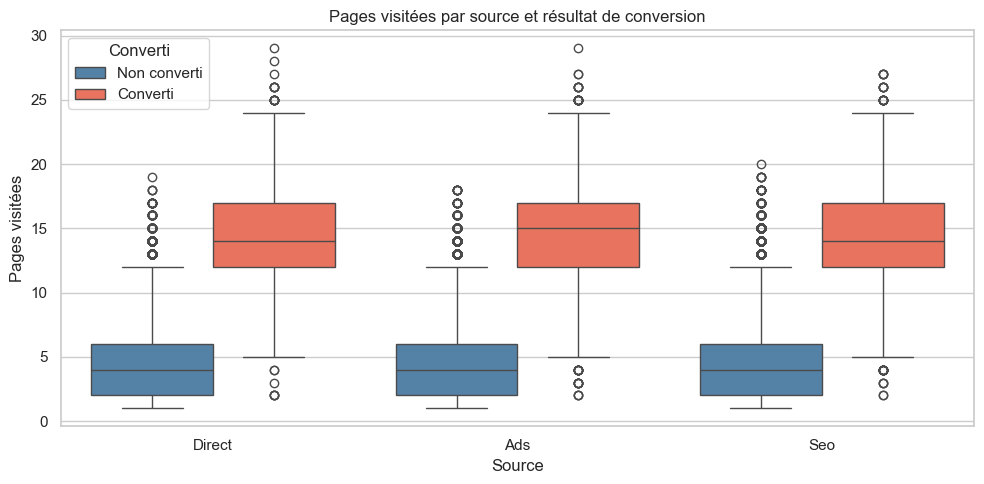

In [18]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='source', y='total_pages_visited',
            hue='converted', palette={0: 'steelblue', 1: 'tomato'})
plt.title('Pages visitées par source et résultat de conversion')
plt.xlabel('Source')
plt.ylabel('Pages visitées')
handles, _ = plt.gca().get_legend_handles_labels()
plt.legend(handles, ['Non converti', 'Converti'], title='Converti')
plt.tight_layout()
plt.show()

**Observation :** Quelle que soit la source, les convertis ont systématiquement visité plus de pages. Le pattern est cohérent sur Direct, Ads et SEO.

## 8. Synthèse

| Variable | Lien avec la conversion | Remarque |
|---|---|---|
| `total_pages_visited` | Fort (corrélation 0.39) | Meilleur prédicteur |
| `new_user` | Modéré — anciens users convertissent plus | À encoder en feature |
| `country` | Modéré — Allemagne > US > UK > Chine | Chine très faible |
| `source` | Faible — différences minimes | Peu discriminant |
| `age` | Faible | Quelques outliers à gérer |

**Points à traiter dans la modélisation :**
- Déséquilibre de classes fort (~3% de positifs) → utiliser `class_weight='balanced'` ou F1-score
- Valeurs aberrantes sur `age` (> 80 ans)
- Encodage de `country` et `source` (OneHot ou ordinal selon le modèle)